## Charger le split déja crée dans 'clustering_stratifie.ipynb' 

In [2]:

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb


ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

X = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y = pd.read_parquet(DATA_PROCESSED / "Y.parquet")

idx_train = np.load(DATA_PROCESSED / "idx_train.npy")
idx_test  = np.load(DATA_PROCESSED / "idx_test.npy")

X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]

Y_train = Y.iloc[idx_train]
Y_test  = Y.iloc[idx_test]

print(X_train.shape, X_test.shape)



(439976, 110) (109995, 110)


## Créer un validation set
#### On conserve la meme stratification en utilisant 'stratum-final'

In [ ]:


labels = pd.read_parquet(
    DATA_PROCESSED / "cluster_labels.parquet"
)

stratum_train = labels.iloc[idx_train]["stratum_final"]

X_train_final, X_val, Y_train_final, Y_val, strat_train, strat_val = train_test_split(
    X_train,
    Y_train,
    stratum_train,
    test_size=0.2,
    random_state=42,
    stratify=stratum_train
)


total = len(X_train_final) + len(X_val) + len(X_test)

print(f"Train : {X_train_final.shape} ({len(X_train_final)/total:.1%})")
print(f"Val   : {X_val.shape} ({len(X_val)/total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/total:.1%})")



Train : (351980, 110) (64.0%)
Val   : (87996, 110) (16.0%)
Test  : (109995, 110) (20.0%)


## Baseline naive

In [4]:
results_dummy = {}

print("===== Baseline naïve (médiane) par cible =====\n")

for target in Y.columns:

    # prédiction naïve = médiane du train
    median_value = Y_train_final[target].median()
    y_pred = np.full(len(Y_test), median_value)

    # métriques
    rmse = np.sqrt(mean_squared_error(Y_test[target], y_pred))
    mae  = mean_absolute_error(Y_test[target], y_pred)
    r2   = r2_score(Y_test[target], y_pred)

    results_dummy[target] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    print(f"{target}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  R²   = {r2:.4f}\n")


===== Baseline naïve (médiane) par cible =====

out.electricity.total.energy_consumption..kwh
  RMSE = 8809.83
  MAE  = 5966.36
  R²   = -0.0568

out.natural_gas.total.energy_consumption..kwh
  RMSE = 18181.37
  MAE  = 10319.81
  R²   = -0.2563

out.fuel_oil.total.energy_consumption..kwh
  RMSE = 7089.03
  MAE  = 1259.82
  R²   = -0.0326

out.propane.total.energy_consumption..kwh
  RMSE = 6294.01
  MAE  = 1114.30
  R²   = -0.0324

out.emissions.total.lrmer_mid_case_25..co2e_kg
  RMSE = 4617.80
  MAE  = 3239.35
  R²   = -0.0722



## Definition du modèle lightgbm 

In [5]:
SEED = 42

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)

## Entrainer LightGBM

In [6]:
results = {}

for target in Y.columns:

    print(f"\n========== {target} ==========")

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_final,
        Y_train_final[target],
        eval_set=[(X_val, Y_val[target])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    pred = model.predict(X_test)

    results[target] = {
        "RMSE": np.sqrt(mean_squared_error(Y_test[target], pred)),
        "MAE": mean_absolute_error(Y_test[target], pred),
        "R2": r2_score(Y_test[target], pred)
    }

pd.DataFrame(results).T.sort_values("R2", ascending=False)



========== out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 11761.455661

========== out.natural_gas.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 10593.506178

========== out.fuel_oil.total.energy_

,RMSE,MAE,R2
out.emissions.total.lrmer_mid_case_25..co2e_kg,1316.371481,722.961992,0.912873
out.natural_gas.total.energy_consumption..kwh,5885.243279,2922.874115,0.868363
out.electricity.total.energy_consumption..kwh,3392.826772,1709.450682,0.843266
out.fuel_oil.total.energy_consumption..kwh,4058.474544,951.471885,0.661555
out.propane.total.energy_consumption..kwh,4382.695189,1150.142755,0.499438


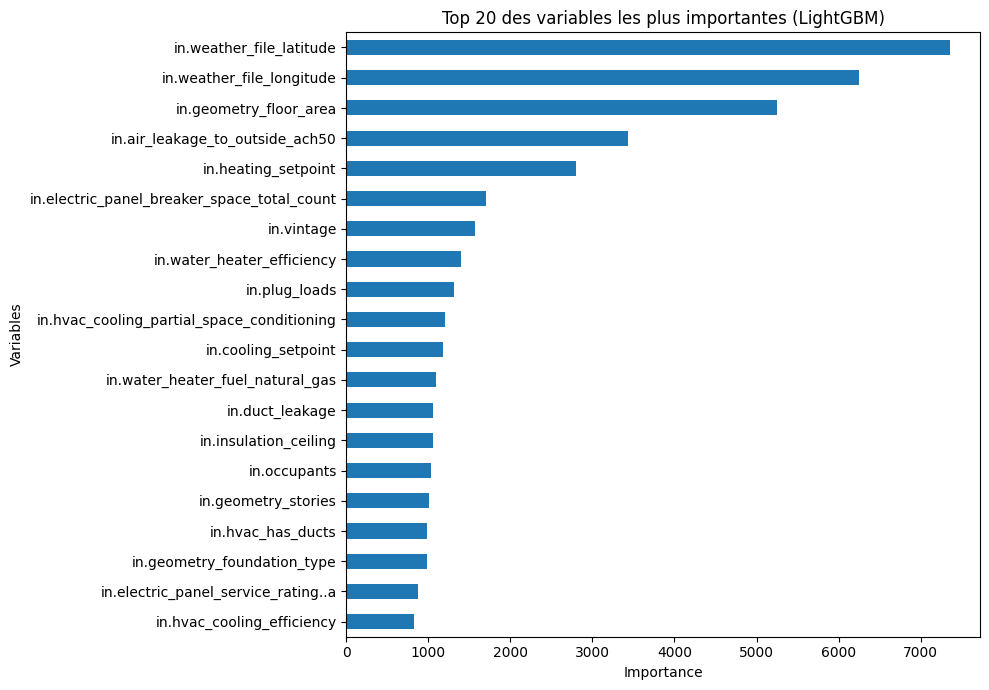


Top 20 variables importantes :
in.weather_file_latitude                       7357
in.weather_file_longitude                      6246
in.geometry_floor_area                         5247
in.air_leakage_to_outside_ach50                3437
in.heating_setpoint                            2805
in.electric_panel_breaker_space_total_count    1707
in.vintage                                     1572
in.water_heater_efficiency                     1395
in.plug_loads                                  1312
in.hvac_cooling_partial_space_conditioning     1197
in.cooling_setpoint                            1178
in.water_heater_fuel_natural_gas               1091
in.duct_leakage                                1054
in.insulation_ceiling                          1051
in.occupants                                   1037
in.geometry_stories                            1002
in.hvac_has_ducts                               982
in.geometry_foundation_type                     980
in.electric_panel_service_rating

In [7]:

importance = pd.Series(
    model.feature_importances_,
    index=X_train_final.columns
)

top20 = importance.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Variables")
plt.title("Top 20 des variables les plus importantes (LightGBM)")
plt.tight_layout()
plt.show()

print("\nTop 20 variables importantes :")
print(top20)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 11761.455661
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 110
[LightGBM] [Info] Start training from score 10593.506178
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory 

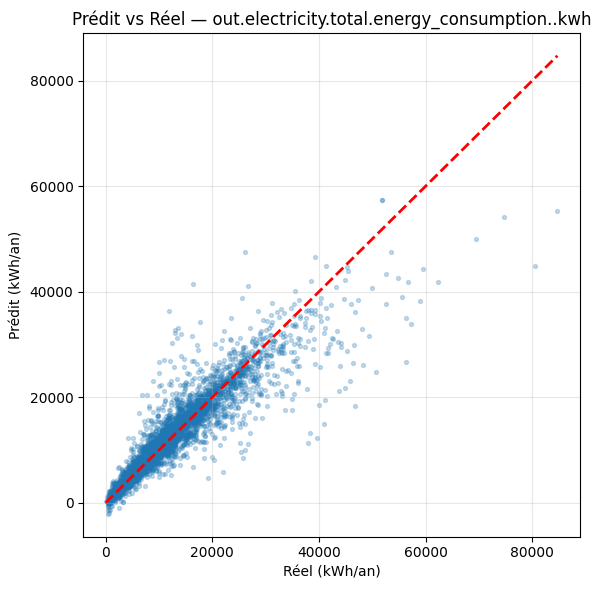

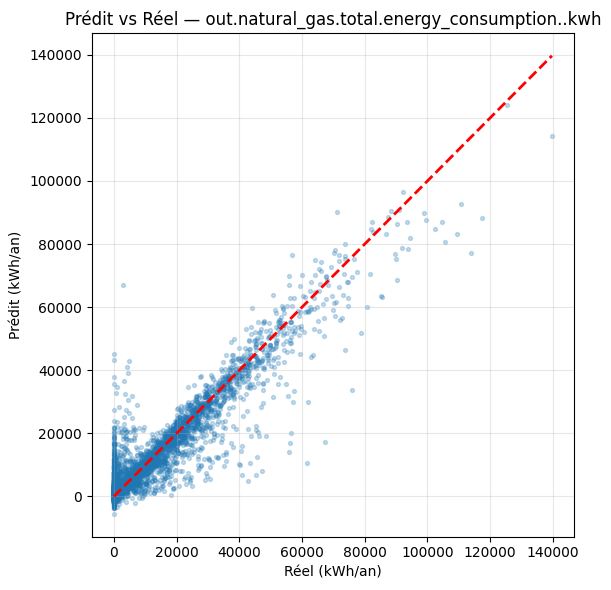

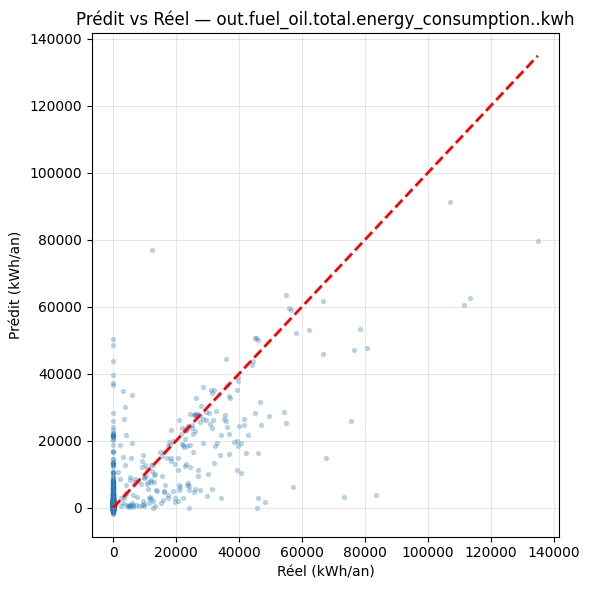

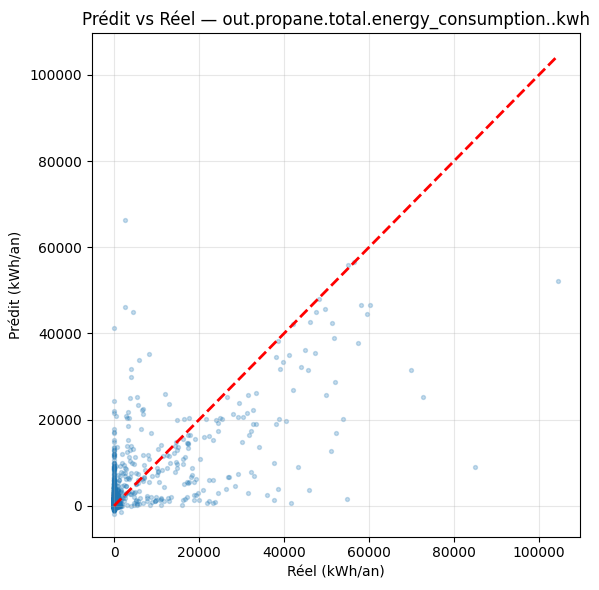

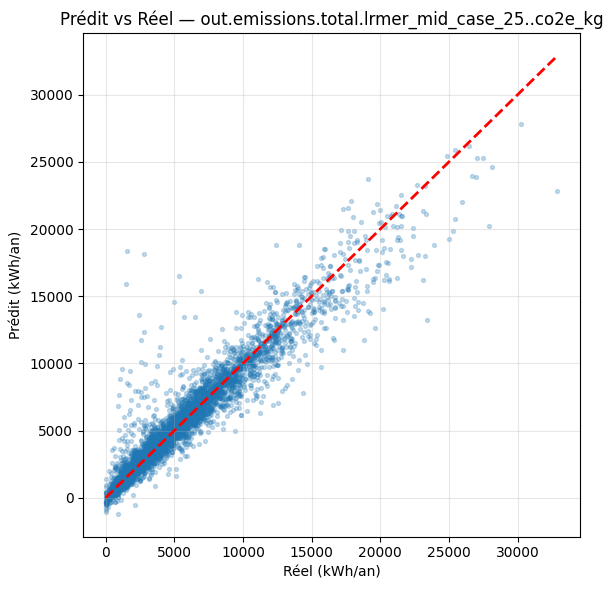

In [8]:
rng = np.random.default_rng(42)

n_points = 5000 #rdm

models = {}
y_pred_dict = {}

for target in Y.columns:

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(
        X_train_final,
        Y_train_final[target],
        eval_set=[(X_val, Y_val[target])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    models[target] = model

    # on stocke les prédictions test
    y_pred_dict[target] = model.predict(X_test)

for target in Y.columns:

    y_true = Y_test[target]
    y_pred = model.predict(X_test) if len(Y.columns) == 1 else y_pred_dict[target]

    # échantillon
    n = min(n_points, len(y_true))

    sample = rng.choice(len(y_true), size=n, replace=False)

    y_true_sample = y_true.iloc[sample]
    y_pred_sample = y_pred[sample]

    # plot
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_true_sample,
        y_pred_sample,
        alpha=0.25,
        s=8
    )

    # diagonale parfaite
    max_value = max(y_true_sample.max(), y_pred_sample.max())

    plt.plot(
        [0, max_value],
        [0, max_value],
        "r--",
        linewidth=2
    )

    plt.xlabel("Réel (kWh/an)")
    plt.ylabel("Prédit (kWh/an)")
    plt.title(f"Prédit vs Réel — {target}")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
